## **Setup and Imports**




In [1]:
# Import necessary libraries
import pickle
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (7,4)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## **Mount Google Drive and Load Data**

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
os.chdir('/content/drive/My Drive/Colab Notebooks')

from google.colab import files
files.upload()

[f for f in os.listdir() if 'coin' in f.lower()] # Just to check you have coins.csv and noisy_coins.csv in the right location!

Saving coins.csv to coins (1).csv
Saving noisy_coins.csv to noisy_coins (1).csv


['coins.csv', 'noisy_coins.csv', 'coins (1).csv', 'noisy_coins (1).csv']

## **Dataset Visualization**

In [4]:
# Load the dataset 'coins.csv' using pandas' read_csv function.
# Make sure coins.csv is in the directory where you're using Jupyter
# If using Google Colab, upload the coins file to the directory by usinf upload in the toolbar on the left
coins = pd.read_csv('coins.csv')
coins.tail(5)

,reflectance,weight,denomination
174,26.650728,5.420213,2
175,27.492055,6.149025,2
176,29.157397,7.035390,2
177,27.741846,5.032280,2
178,27.629866,5.395878,2


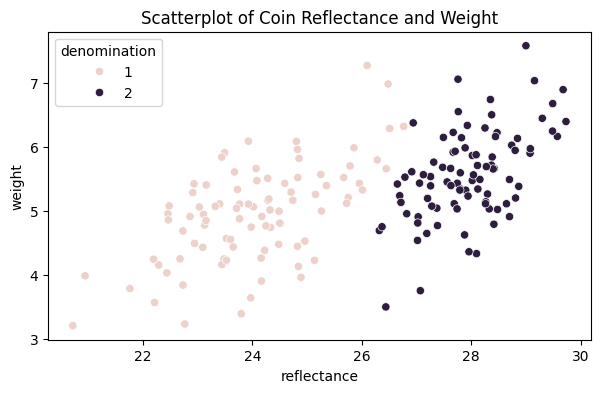

In [5]:
# Visualize the data distribution using a scatterplot
sns.scatterplot(x="reflectance", y="weight", data=coins, hue="denomination")
plt.title("Scatterplot of Coin Reflectance and Weight")
plt.show()

## **Data Preparation**

In [7]:
# [STUDENT SECTION: Prepare the data for training and testing]

# Prepare the input features (X)
X = coins[["reflectance", "weight"]].to_numpy()

# Convert the denomination values (1 and 2) to binary labels (0 and 1) for binary classification.
# Subtract 1 from denomination so class 1 -> 0, class 2 -> 1
y = (coins["denomination"] - 1).to_numpy()

# Split the data into training and testing sets using train_test_split.
# 80/20 split, random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input features using StandardScaler
scaler = StandardScaler()
# fit_transform on training data: learns mean/std AND transforms
X_train = scaler.fit_transform(X_train)
# transform on test data: uses the SAME mean/std from training (no re-fitting)
X_test = scaler.transform(X_test)

## **Build and Train the Model**

In [8]:
# [STUDENT SECTION: Define and compile the model]

# Build a Sequential neural network
model = Sequential([
    Input(shape=(2,)),          # 2 input features: reflectance and weight
    Dense(16, activation='relu'), # Hidden layer 1: 16 neurons, ReLU activation
    Dense(8, activation='relu'),  # Hidden layer 2: 8 neurons, ReLU activation
    Dense(1, activation='sigmoid') # Output layer: 1 neuron, sigmoid for binary classification
])

# Compile: Adam optimizer, binary crossentropy loss (standard for binary classification)
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# EarlyStopping: stop training if val_loss doesn't improve for 10 epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, callbacks=[early_stopping])


Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5000 - loss: 0.6423 - val_accuracy: 0.4138 - val_loss: 0.6593
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5000 - loss: 0.6312 - val_accuracy: 0.4828 - val_loss: 0.6477
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5088 - loss: 0.6209 - val_accuracy: 0.5517 - val_loss: 0.6359
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5263 - loss: 0.6102 - val_accuracy: 0.5862 - val_loss: 0.6244
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5439 - loss: 0.6003 - val_accuracy: 0.5862 - val_loss: 0.6125
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6053 - loss: 0.5906 - val_accuracy: 0.6207 - val_loss: 0.6009
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6667 - loss: 0.5807 - val_accuracy: 0.7241 - val_loss: 0.5892
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6930 - loss: 0.5711 - val_accuracy: 0.7586 - val_loss

## **Evaluate the Model**

**experiement with the accuracy if used only 1 middle layer vs. 2 and so on**

In [9]:
# [STUDENT SECTION: Evaluate the model]
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0652
Test Accuracy: 1.0000


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


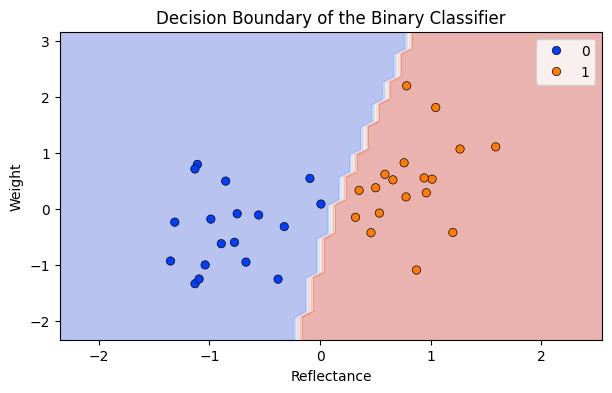

In [10]:
# Plot the Decision Boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.round(Z).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.coolwarm)
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y.flatten(), palette='bright', edgecolor="k")
    plt.xlabel('Reflectance')
    plt.ylabel('Weight')
    plt.title('Decision Boundary of the Binary Classifier')
    plt.show()

# Call with scaled test data and labels
plot_decision_boundary(X_test, y_test, model)


In [11]:
# Save the trained model
model.save('model.h5')
print('Model saved to model.h5')

# Load the saved model
loaded_model = tf.keras.models.load_model('model.h5')
print('Model loaded from model.h5')


Model saved to model.h5
Model loaded from model.h5


In [12]:
# Evaluate the loaded model on test data
predictions = loaded_model.predict(X_test)
predicted_labels = np.round(predictions).flatten()  # Round probabilities to 0/1, flatten from 2D to 1D

# Compute accuracy by comparing predictions to true labels
accuracy = np.mean(predicted_labels == y_test)
print(f"Loaded model test accuracy: {accuracy:.4f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Loaded model test accuracy: 1.0000


### **Eval on noisy data**

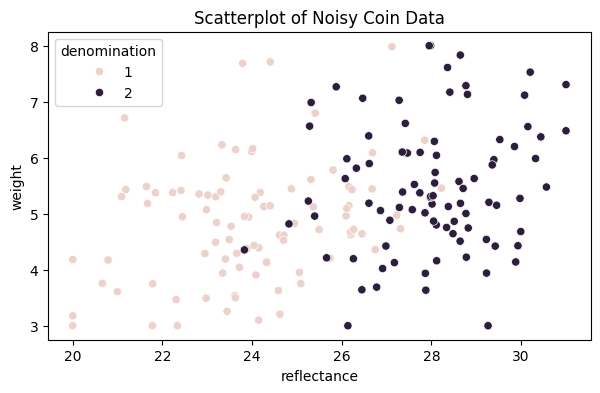

In [13]:
# Load and visualize noisy data
noisy_coins = pd.read_csv('noisy_coins.csv')

# Visualize the noisy data distribution
sns.scatterplot(x="reflectance", y="weight", data=noisy_coins, hue="denomination")
plt.title("Scatterplot of Noisy Coin Data")
plt.show()


In [14]:
# Prepare noisy data features and labels
X_noisy = noisy_coins[["reflectance", "weight"]].to_numpy()
y_noisy = (noisy_coins["denomination"] - 1).to_numpy()

# IMPORTANT: Use the SAME scaler fitted on training data
X_noisy_scaled = scaler.transform(X_noisy)

# Predict and convert probabilities to binary labels
noisy_predictions = loaded_model.predict(X_noisy_scaled)
noisy_predicted_labels = np.round(noisy_predictions).flatten()

# Compute accuracy
noisy_accuracy = np.mean(noisy_predicted_labels == y_noisy)
print(f"Noisy data accuracy: {noisy_accuracy:.4f}")


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Noisy data accuracy: 0.8603


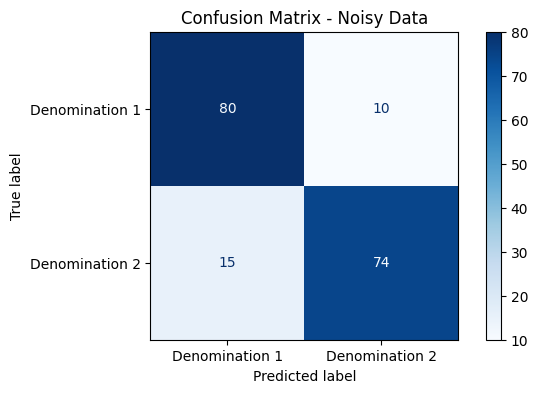

                precision    recall  f1-score   support

Denomination 1       0.84      0.89      0.86        90
Denomination 2       0.88      0.83      0.86        89

      accuracy                           0.86       179
     macro avg       0.86      0.86      0.86       179
  weighted avg       0.86      0.86      0.86       179



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_noisy, noisy_predicted_labels)

# Visualize confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Denomination 1', 'Denomination 2'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Noisy Data')
plt.show()

# Print precision, recall, and F1-score
print(classification_report(y_noisy, noisy_predicted_labels, target_names=['Denomination 1', 'Denomination 2']))
